In [150]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

parquet_file = Path("./results.parquet")
df = pd.read_parquet(parquet_file)

HUE_ORDER = ["prolog", "EdgeWise", "EdgeWise (cr)"]
COL_ORDER = ["arFarming", "distSecurity", "speakToMe"]
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Set FONT SIZE of x-axis and y-axis, legend, etc.
FONT_SIZE = 20
rc = {
    "axes.labelsize": FONT_SIZE+2,
    "axes.labelpad": 8,
    "font.size": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "legend.title_fontsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
}

pd.set_option("display.max_rows", None)
plt.rcParams.update(rc)
BAR_TEXT_KWARGS = {"fontsize": 17.5, "fontweight": "bold", "ha": "center", "va": "bottom", "zorder": 99}

df = df[df["version"].isin(HUE_ORDER)]

In [151]:
grouping_columns = ["n_event", "topology", "version", "nodes", "application_id", "seed"]
# Identify the groups where "is_placed" is False
events_to_remove = df[(df["callback_id"] == "is_placed") & (df["value"] == "False")][
    grouping_columns
].drop_duplicates()

# Perform an anti-join to remove groups
old_shape = df.shape
df = df.merge(events_to_remove, on=grouping_columns, how="left", indicator=True)
df = df[df["_merge"] == "left_only"].drop(columns=["_merge"])
print(f"Removed {old_shape[0] - df.shape[0]} events")

Removed 29755 events


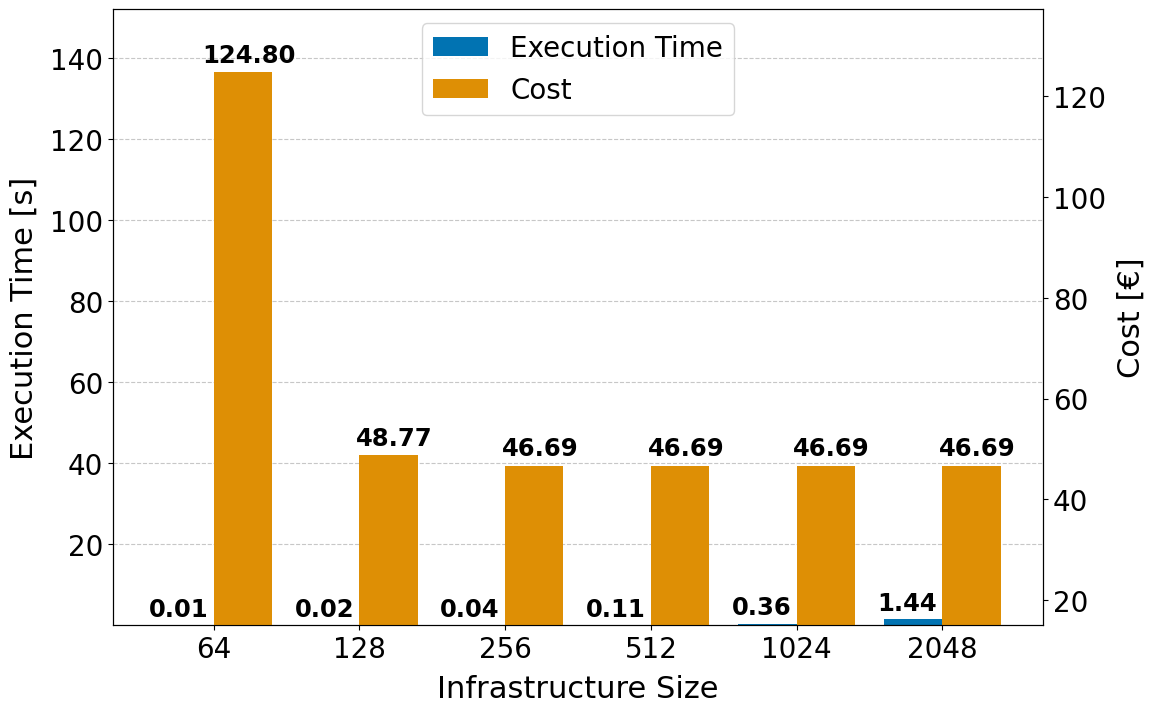

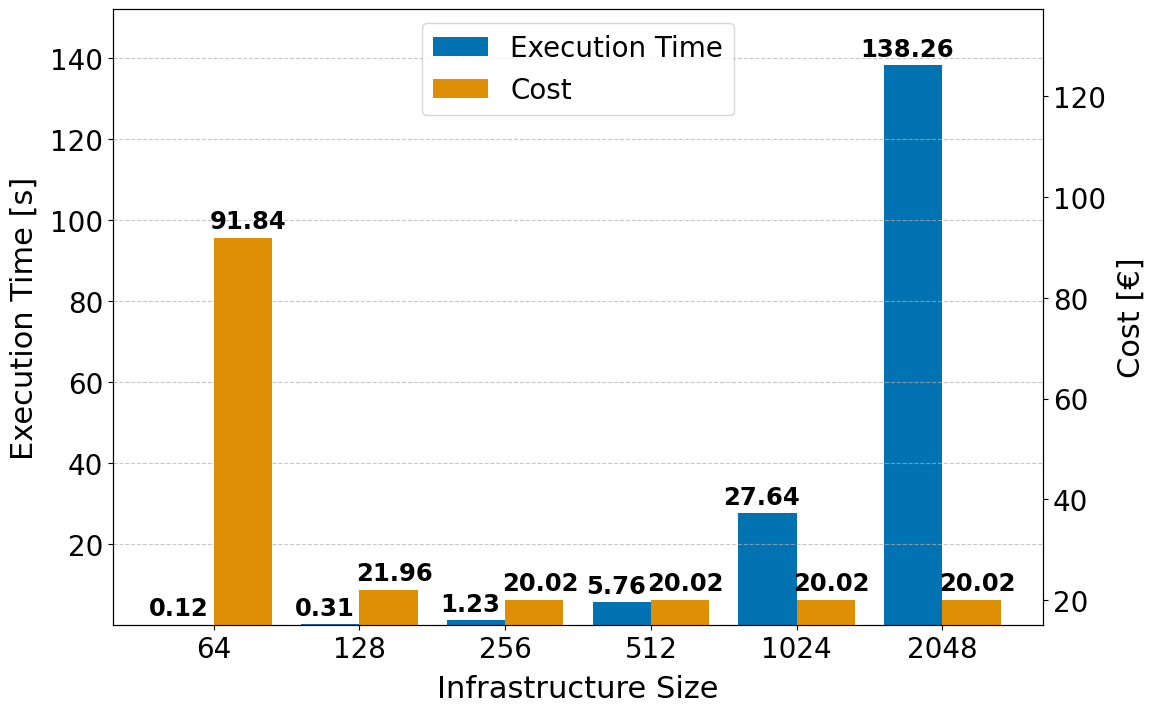

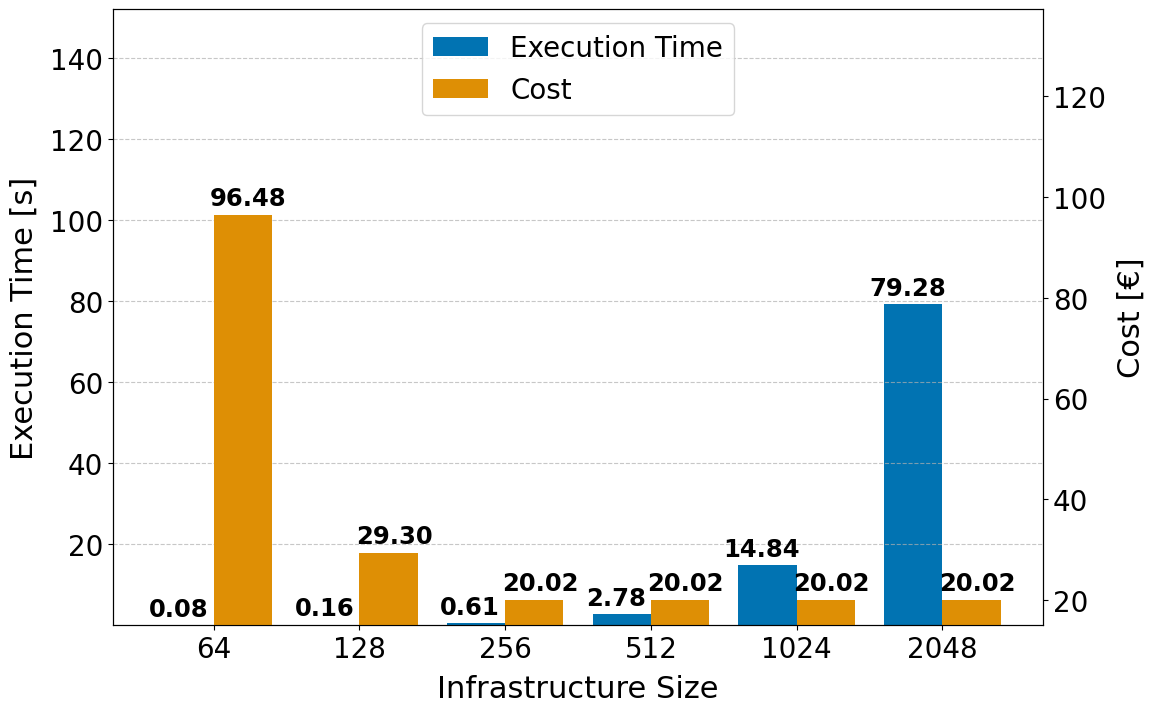

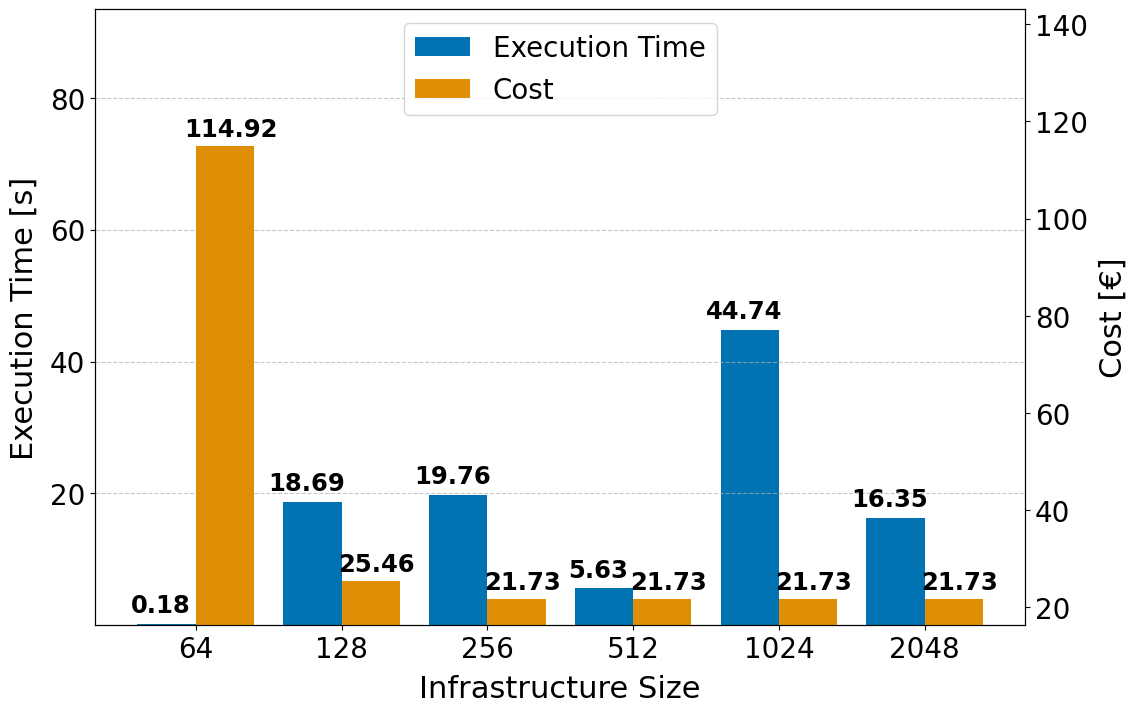

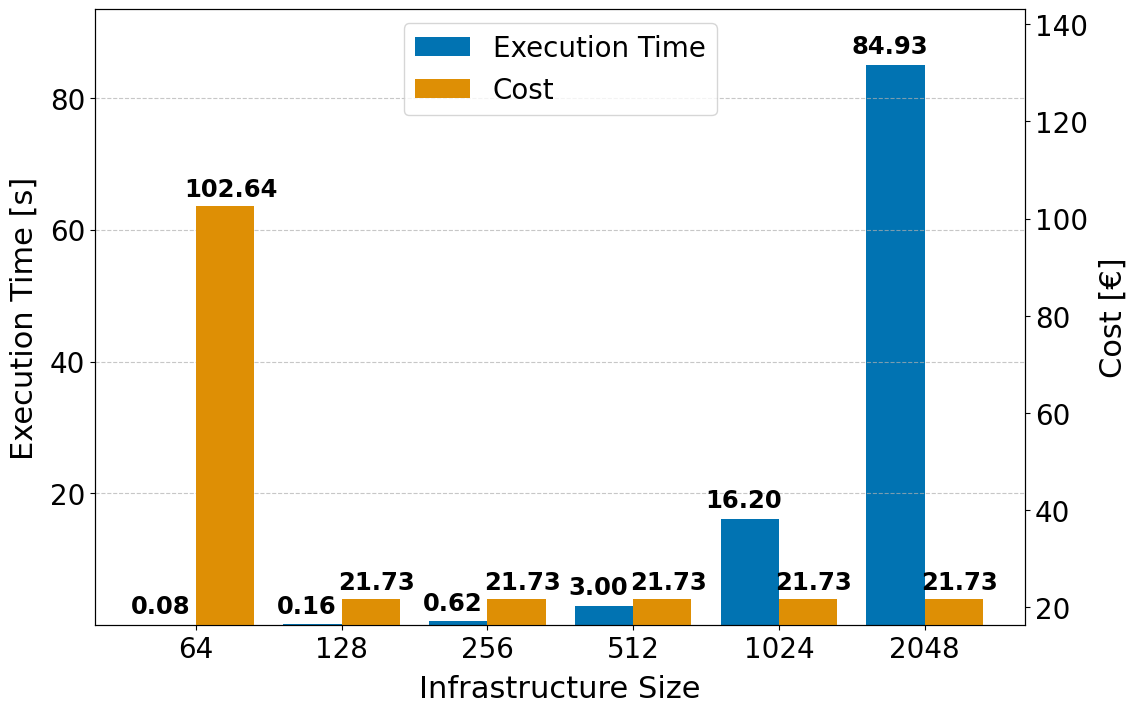

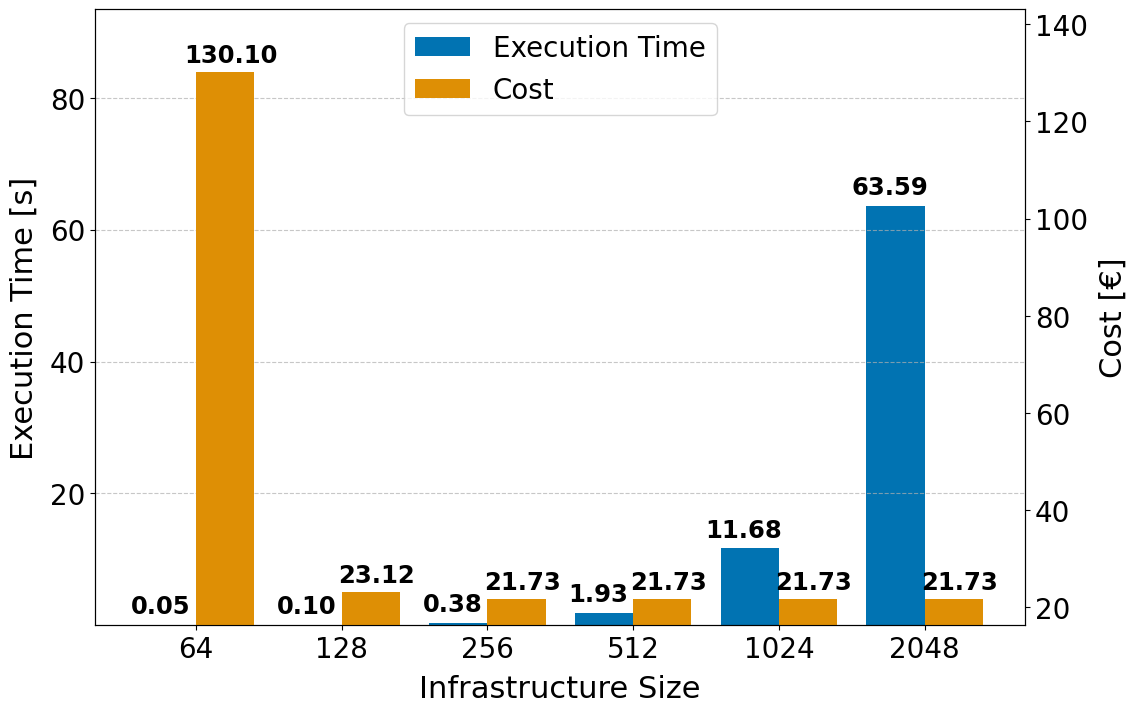

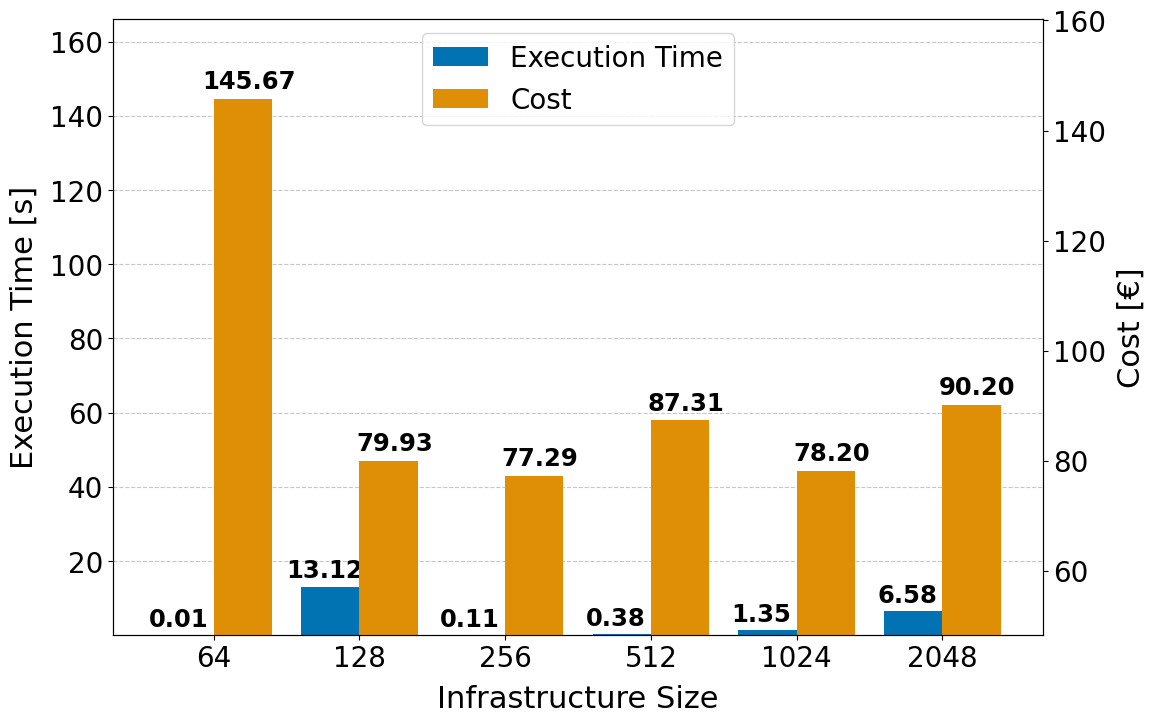

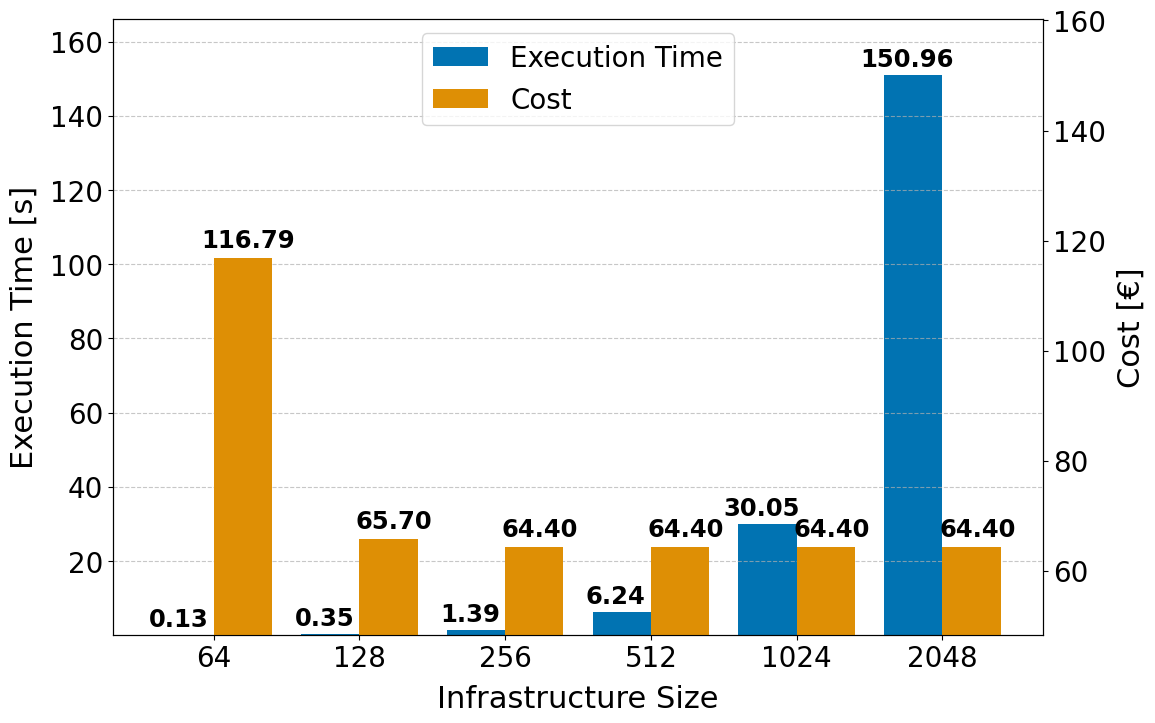

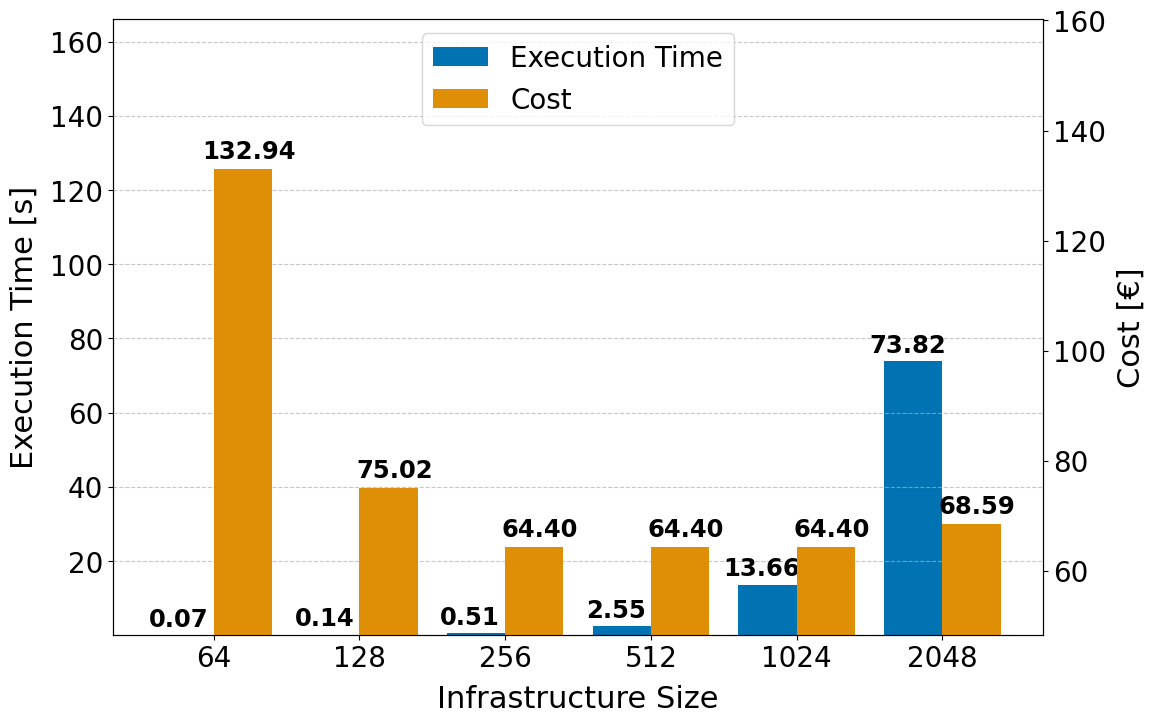

In [152]:
results = []

df_filtered = df[
    df["callback_id"].isin(["cost", "execution_time"]) & (df["value"] != "-1")
]
df_filtered.loc[:, "value"] = df_filtered["value"].astype(float)

df_agg = (
    df_filtered.groupby(["application_id", "nodes", "version", "callback_id"])["value"]
    .mean()
    .unstack()
    .reset_index()
)
color_execution_time, color_cost = sns.color_palette("colorblind", 2)

app_limits = {}

for app_id in df_agg["application_id"].unique():
    df_app = df_agg[df_agg["application_id"] == app_id]
    app_limits[app_id] = {
        "min_exec_time": df_app["execution_time"].min(),
        "max_exec_time": df_app["execution_time"].max(),
        "min_cost": df_app["cost"].min(),
        "max_cost": df_app["cost"].max(),
    }

# Create individual plots for each (application_id, version)
for app_id in df_agg["application_id"].unique():
    for version in HUE_ORDER:
        df_app_version = df_agg[
            (df_agg["application_id"] == app_id) & (df_agg["version"] == version)
        ]

        if df_app_version.empty:
            continue

        df_app_version = df_app_version.sort_values("nodes")

        fig, ax = plt.subplots(figsize=(12, 8))
        ax2 = ax.twinx()

        limits = app_limits[app_id]

        bar_width = 0.4
        x_positions = np.arange(len(df_app_version["nodes"]))

        bars1 = ax.bar(
            x_positions - bar_width / 2,
            df_app_version["execution_time"],
            color=color_execution_time,
            width=bar_width,
            label="Execution Time",
        )
        bars2 = ax2.bar(
            x_positions + bar_width / 2,
            df_app_version["cost"],
            color=color_cost,
            width=bar_width,
            label="Cost",
        )

        ax.set_ylim(limits["min_exec_time"] * 0.75, limits["max_exec_time"] * 1.1)
        ax2.set_ylim(limits["min_cost"] * 0.75, limits["max_cost"] * 1.1)

        # ax.set_title(f"application_id = {app_id}  |  version = {version}")
        ax.set_xlabel("Infrastructure Size")
        ax.set_ylabel("Execution Time [s]")
        ax2.set_ylabel("Cost [€]")

        ax.set_xticks(x_positions)
        ax.set_xticklabels(df_app_version["nodes"])

        x_offset = 0.04
        y_offset = 1
        for bar in bars1:
            height = bar.get_height()
            ax.text(
                -x_offset + bar.get_x() + bar.get_width() / 2,
                height + y_offset,
                f"{height:.2f}",
                **BAR_TEXT_KWARGS,
            )

        for bar in bars2:
            height = bar.get_height()
            ax2.text(
                x_offset + bar.get_x() + bar.get_width() / 2,
                height + y_offset,
                f"{height:.2f}",
                **BAR_TEXT_KWARGS,
            )

        handles = [bars1, bars2]
        labels = ["Execution Time", "Cost"]
        ax.legend(handles, labels, loc="upper center")

        ax.grid(axis="y", linestyle="--", alpha=0.7)

        # plt.tight_layout()
        path = PLOTS_DIR / f"time_cost-{app_id}-{version}.pdf"
        path.parent.mkdir(exist_ok=True, parents=True)
        plt.savefig(path, format="pdf", dpi=600)
        plt.show()

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(30, 15))
axes = axes.flatten()
index = 0

for app_id in df_agg["application_id"].unique():
    for version in HUE_ORDER:
        if index >= 9:
            break

        df_app_version = df_agg[
            (df_agg["application_id"] == app_id) & (df_agg["version"] == version)
        ]
        if df_app_version.empty:
            continue

        df_app_version = df_app_version.sort_values("nodes")
        ax = axes[index]
        ax2 = ax.twinx()

        limits = app_limits[app_id]

        bar_width = 0.4
        x_positions = np.arange(len(df_app_version["nodes"]))

        bars1 = ax.bar(
            x_positions - bar_width / 2,
            df_app_version["execution_time"],
            color=color_execution_time,
            width=bar_width,
            label="Execution Time",
        )
        bars2 = ax2.bar(
            x_positions + bar_width / 2,
            df_app_version["cost"],
            color=color_cost,
            width=bar_width,
            label="Cost",
        )

        ax.set_ylim(limits["min_exec_time"] * 0.75, limits["max_exec_time"] * 1.1)
        ax2.set_ylim(limits["min_cost"] * 0.75, limits["max_cost"] * 1.1)

        ax.set_title(f"application_id = {app_id} | version = {version}")
        ax.set_xlabel("Nodes")
        ax.set_ylabel("Execution Time [s]")
        ax2.set_ylabel("Cost [€]")

        ax.set_xticks(x_positions)
        ax.set_xticklabels(df_app_version["nodes"])

        for bar in bars1:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.2f}",
                **BAR_TEXT_KWARGS,
            )

        for bar in bars2:
            height = bar.get_height()
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.2f}",
                **BAR_TEXT_KWARGS,
            )

        ax.grid(axis="y", linestyle="--", alpha=0.7)
        index += 1

# Remove unused subplots
for j in range(index, 9):
    fig.delaxes(axes[j])

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "time_cost_grid.pdf", format="pdf", dpi=600)
plt.show()